# Where a budget decision comes from

One decision, taken apart. Set `AT` below to any moment — `None` for now, or an ISO
timestamp like `"2026-10-03T21:30"` — and run the whole notebook: every
measurement, every intermediate value and the arithmetic between them is printed in
the order the pipeline computes it.

Nothing here recomputes what `release/aqm.py` computes. Each number comes back from
`aqm.predict()` or `aqm.budget()`, or out of the CSVs they read — a second copy of
a formula in a notebook is the copy a human ends up trusting.

| Stage | Question | Section |
|---|---|---|
| 1 ingestion | What happened? | §1 the meter, §2 the 5-minute table |
| 2 prediction | How much will the user still want? | §3 |
| 3 budgeting | How much may be spent, and by when? | §4, §5 |
| — | And how does that change over a day? | §6 the sweep |

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import explain
from explain import *

# ---- the two knobs -------------------------------------------------------
AT      = None      # None = now; or "2026-10-03T21:30"; or an epoch int
AGENT   = "claude"  # "claude" or "codex"
REFRESH = True      # append any new readings first (safe: data/ is rebuildable)
# -------------------------------------------------------------------------

aqm = explain.connect(refresh=REFRESH)
at = moment(AT)
prediction, decision = decide(at)
block = decision["agents"][AGENT]
print("\ndeciding as of %s  (config_hash %s)" % (aqm.shown(at), decision["config_hash"]))

reading   /Users/jeanlescut/opt/agent-quota-maximizer
raw logs  /Users/jeanlescut/opt/agent-usage-tracker
agents    claude, codex · config_hash 0294287a
refreshed {"claude": {"readings": 6, "slots": 3, "recent_windows": 18}, "codex": {"readings": 1, "slots": 3, "recent_windows": 43}}
  claude  last reading 2026-10-05 16:10:47 +0200  (1 min old)
  codex   last reading 2026-10-05 16:00:08 +0200  (12 min old)

deciding as of 2026-10-05 16:11:44 +0200  (config_hash 0294287a)


## 1. The meter — the only thing actually measured

Everything downstream is arithmetic on this. `window_used_pct` is the **account's** usage
of the open 5-hour window, in percent; there is no per-session figure and there
cannot be, because the meter is one account-level number.

Three things to look for in the plot:

- **the step line** is the meter. It only ever rises inside a window, which is the
  property the *drop_stale_readings* exploits: of several readings at the same level, only the
  first is kept, so ~167,000 raw readings become ~830 rows.
- **grey ticks at 0** are slots with **no window open** — about three quarters of
  all elapsed time. That gap is the waste this project exists to recover.
- **red triangles** are slots where `was_human_active > 0`: a reading arrived from a
  session that is not ours, so the user was demonstrably at the keyboard, whether
  or not the meter had moved yet.

<Axes: title={'center': 'claude — the 5-hour meter, last 12 h'}, ylabel='% of the 5-hour window'>

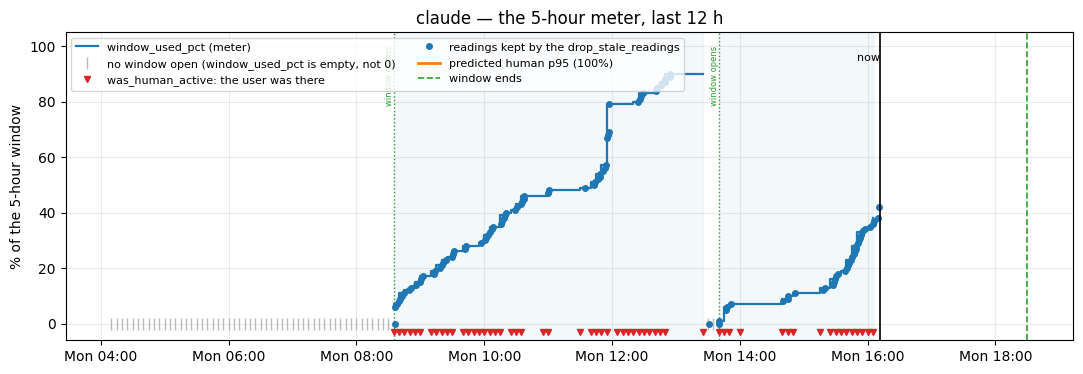

In [2]:
plot_meter(AGENT, at, prediction, hours=12)

In [3]:
# The readings themselves, as kept. `window_end_ts` is the window identity: it is
# rounded to the minute, because both agents report one window's reset at two
# different instants and the raw value splits a window in two.
meter_frame(AGENT, at - 6 * 3600, at)[
    ["observed_dt", "window_used_pct", "week_used_pct", "window_end_dt", "source", "agent_session_id"]
].tail(12)

,observed_dt,window_used_pct,week_used_pct,window_end_dt,source,agent_session_id
63,2026-10-05 15:49:25 +0200,28.0,59.0,2026-10-05 18:30:00 +0200,claude,None
64,2026-10-05 15:50:54 +0200,29.0,58.0,2026-10-05 18:30:00 +0200,claude_statusline,bc36b32e-8a0c-437f-b8e8-7d8bf48c210c
65,2026-10-05 15:51:32 +0200,30.0,59.0,2026-10-05 18:30:00 +0200,claude,None
66,2026-10-05 15:52:48 +0200,31.0,59.0,2026-10-05 18:30:00 +0200,claude_statusline,bc36b32e-8a0c-437f-b8e8-7d8bf48c210c
67,2026-10-05 15:53:40 +0200,32.0,59.0,2026-10-05 18:30:00 +0200,claude,None
68,2026-10-05 15:54:58 +0200,33.0,59.0,2026-10-05 18:30:00 +0200,claude_statusline,bc36b32e-8a0c-437f-b8e8-7d8bf48c210c
69,2026-10-05 15:57:54 +0200,34.0,59.0,2026-10-05 18:30:00 +0200,claude,None
70,2026-10-05 16:02:18 +0200,35.0,60.0,2026-10-05 18:30:00 +0200,claude,None
71,2026-10-05 16:05:09 +0200,36.0,59.0,2026-10-05 18:30:00 +0200,claude_statusline,f3080d58-9777-4b7a-8618-6b1df0bce191
72,2026-10-05 16:05:36 +0200,37.0,59.0,2026-10-05 18:30:00 +0200,claude_statusline,f3080d58-9777-4b7a-8618-6b1df0bce191


## 2. The 5-minute table — what the rate is measured over

`aqm ingest` turns those readings into one row per 5 minutes per agent. These are
exactly the rows `burn_rate()` sums over `BURN_LOOKBACK_MINUTES`, with the running total, so
the rate reported in §3 can be checked by eye.

- `slot_window_used_pct` — how much the meter moved in this slot.
- `slot_window_human_pct` — how much of that was the **user's**, not ours. Empty when our
  worker and the user overlapped: the split cannot be measured, so bounds are kept
  instead of a number being invented (`attribution: censored`), and the
  **upper** bound is what feeds the rate. Predicting more human demand is the
  conservative direction.
- `was_human_active` — confirmed human activity, counted from the **raw** rows before the
  drop_stale_readings. That ordering is the whole reason the tripwire works; see §3.

In [4]:
rows = rate_rows(AGENT, at)
print("BURN_LOOKBACK_MINUTES = %d min · %d slots · %.1f min of span"
      % (aqm.P["BURN_LOOKBACK_MINUTES"], len(rows), rows["minutes"].sum() if len(rows) else 0))
rows

BURN_LOOKBACK_MINUTES = 30 min · 6 slots · 30.0 min of span


,slot,window_used_pct,slot_window_used_pct,slot_window_human_pct,used,censored,attribution,slot_n_readings,was_human_active,n_bot_workers,minutes,cumulative
0,15:40,23.0,4.0,4.0,4.0,False,exact,4,21,0,5.0,4.0
1,15:45,28.0,5.0,5.0,5.0,False,exact,5,4,0,5.0,9.0
2,15:50,33.0,5.0,5.0,5.0,False,exact,5,21,0,5.0,14.0
3,15:55,34.0,1.0,1.0,1.0,False,exact,1,5,0,5.0,15.0
4,16:00,35.0,1.0,1.0,1.0,False,exact,1,3,0,5.0,16.0
5,16:05,38.0,3.0,3.0,3.0,False,exact,3,13,0,5.0,19.0


## 3. Stage 2 — the forecast

```
rate     = max(last_30_min, current_window) burn rate   (percent of a window per minute)
minutes  = the time left in the current window        (no cap, no horizon)
predicted_p95_human_usage_pct  = rate x minutes x SAFETY_MULTIPLIER            clamped to 100
human_reserve_pct = max(MIN_HUMAN_RESERVE_PCT, predicted_p95_human_usage_pct)   what budgeting uses
```

`signal` says which evidence produced the rate, and the distinction matters:

| `signal` | Meaning |
|---|---|
| `S1` | The meter moved in the last `BURN_LOOKBACK_MINUTES`. Reacts fastest. |
| `S1-window` | The window's own average won — what stops a pause reading as idleness: while a window is filling it is never zero. |
| `S2` | The **tripwire**: the meter has not moved, but a reading arrived from a session that is not ours. The user has just started and their first 1% has not landed. The rate is raised to a floor (`ACTIVE_HUMAN_BURN_RATE`), never set by it — the signal says *that* they are active, not how much. |
| `null` | Genuinely idle. |
| `unreadable` | A source could not be read. Comes with `predicted_p95_human_usage_pct: 100`, so misreading it as calm still cannot spend anything. |

The presence floor only works because `was_human_active` is counted **before** the drop_stale_readings. The
drop_stale_readings drops readings carrying no new percentage — which is exactly what a
just-started user looks like — so counting after it deleted the one case the
tripwire exists for, silently.

In [5]:
predict_steps(AGENT, at, prediction)

,step,value,where it comes from
0,human movement in the last BURN_LOOKBACK_MINUTES,0.63333 %/min,based on last_30_min · 19 readings · BURN_LOOK...
1,effective burn rate,0.63333 %/min,"max(last_30_min, current_window), floored by t..."
2,x minutes to the window's end,138 min,always the whole remaining window -- the stage...
3,x SAFETY_MULTIPLIER,1.5,the quantile multiplier on the measured rate
4,= predicted_p95_human_usage_pct,100.0 %,clamped to 100: a forecast is a share of ONE w...
5,-> human_reserve_pct budgeting will use,100.0 %,"max(MIN_HUMAN_RESERVE_PCT = 10.0, the p95)"


## 4. Stage 3 — the window chain and its two ceilings

A **window** is a window, or the part of one on either side of the 7-day reset. The
chain runs from now to that reset, and each window gets a ceiling from **two
independent limits, never multiplied**:

```
max_spend_units_by_quota = 1 - margin - (what this window has already used, open window only)
max_spend_units_by_time  = window hours x BOT_BURN_UNITS_PER_HOUR
ceiling    = max(0, min(max_spend_units_by_quota, max_spend_units_by_time))
```

`limited_by` says which one won. `quota` almost always — `max_spend_units_by_time` only bites on
windows shorter than 54 minutes at today's `BOT_BURN_UNITS_PER_HOUR`, i.e. right before a reset.

`planned_units` comes from the **back-fill**: fill from the last window before the reset,
*backwards*. That is the project's guiding principle in one line — every window
earlier than strictly necessary gets 0, so the user keeps first claim on all of it
until it is about to expire. `left` is the running remainder read top to bottom.

In [6]:
window_frame(block)

,#,from,to,hours,window,human_reserve_pct,max_spend_units_by_quota,max_spend_units_by_time,limited_by,max_spend_units,planned_units,left
0,0,Mon 16:11,Mon 18:30,2.30,True,100.0,-0.42,2.3044,quota,0.0,0.0,3.4515
1,1,Mon 18:35,Mon 21:00,2.42,False,10.0,0.90,2.4167,quota,0.9,0.9,2.5515


<Axes: title={'center': 'claude — the back-fill, in the order it runs: last window first. Orange is the current window = extra_quota_to_spend_units.'}, ylabel='unit'>

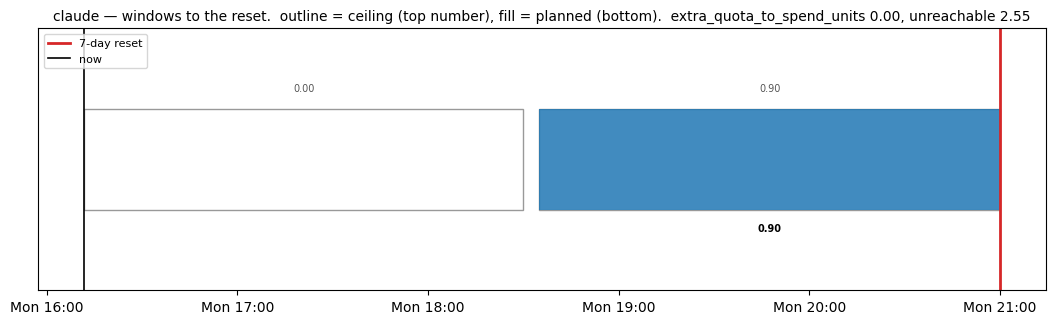

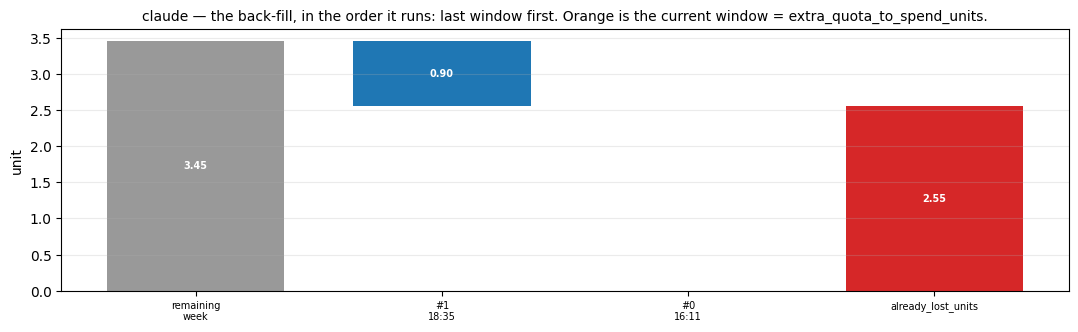

In [7]:
plot_windows(AGENT, block)
plot_backfill(AGENT, block)

## 5. The decision

`extra_quota_to_spend_units` is whatever the back-fill left in the **current** window, and it is 0 on
the great majority of ticks. `already_lost_units` is the part of the week that no
remaining window can absorb: **that number is the waste, measured**, and it is
reported rather than acted on.

Dollar figures are for reading only. Quota arithmetic is done in meter percent,
because percent is the only unit a limit is enforced against.

In [8]:
decision_steps(AGENT, block)

,quantity,value,note
0,7-day meter,61.0 %,the only account-level number there is
1,week_left_units,3.451 unit,(100 - week_used_pct)/100 x WEEK_CAPACITY_UNIT...
2,window used,42 %,subtracted from the open window's max_spend_un...
3,windows to the reset,2,"5h windows + WINDOW_GAP_SECONDS, the last one ..."
4,sum of ceilings,0.900 unit,the most the remaining windows could absorb
5,extra_quota_to_spend_units,0.000 unit (~$0),what the back-fill left in the CURRENT window
6,spend_by_ts,--:--,window end - DEADLINE_MARGIN_SECONDS; null whe...
7,already_lost_units,2.551 unit (~$82),"no window can absorb it: this is the waste, me..."
8,decision,wait,"why, so a 0 never has to be interpreted"


In [9]:
# The identity worth checking by hand: nothing may vanish in the back-fill.
placed = sum(w["planned_units"] for w in block["remaining_windows"]) + block["already_lost_units"]
print("planned + already_loste = %.4f   week_left_units = %.4f   %s"
      % (placed, block["week"]["left_units"],
         "ok" if abs(placed - block["week"]["left_units"]) < 1e-6 else "MISMATCH"))
print(aqm.budget_table(decision))

planned + already_loste = 3.4515   week_left_units = 3.4515   ok
claude · now Mon 16:11 · week ends Mon 21:00 (in 4h48m) · 3.45 units left

  window                   max_spend   planned   left
  [Mon 16:11 – Mon 18:30]     0.00      0.00   3.45
  [Mon 18:35 – Mon 21:00]     0.90      0.90   2.55     (split by the week's end)

  extra_quota_to_spend_units 0.00 · spend by --:-- · already lost 2.55 · wait

codex · now Mon 16:11 · week ends Sat 09:24 (in 113h12m) · 5.58 units left

  window                   max_spend   planned   left
  [Mon 16:11 – Mon 21:11]     0.90      0.00   5.58
  [Mon 21:16 – Tue 02:16]     0.90      0.00   5.58
  [Tue 02:21 – Tue 07:21]     0.90      0.00   5.58
  [Tue 07:26 – Tue 12:26]     0.90      0.00   5.58
  [Tue 12:31 – Tue 17:31]     0.90      0.00   5.58
  [Tue 17:36 – Tue 22:36]     0.90      0.00   5.58
  [Tue 22:41 – Wed 03:41]     0.90      0.00   5.58
  [Wed 03:46 – Wed 08:46]     0.90      0.00   5.58
  [Wed 08:51 – Wed 13:51]     0.90      0.00  

## 6. The same decision, over time

A single tick cannot show whether the system behaves. This replays `predict` →
`budget` at regular past moments and plots the result, which answers the questions
that matter:

- does `extra_quota_to_spend_units` appear **only** near the reset, and not before?
- does `already_lost_units` grow as the reset approaches — i.e. is quota becoming
  unsaveable while we watch?
- did the forecast track the user's real activity, and did the **S2** tripwire fire
  before the meter moved rather than after?

This is also the shape of the backtest: the same two read-only stages, chained with
`--at`, writing nothing.

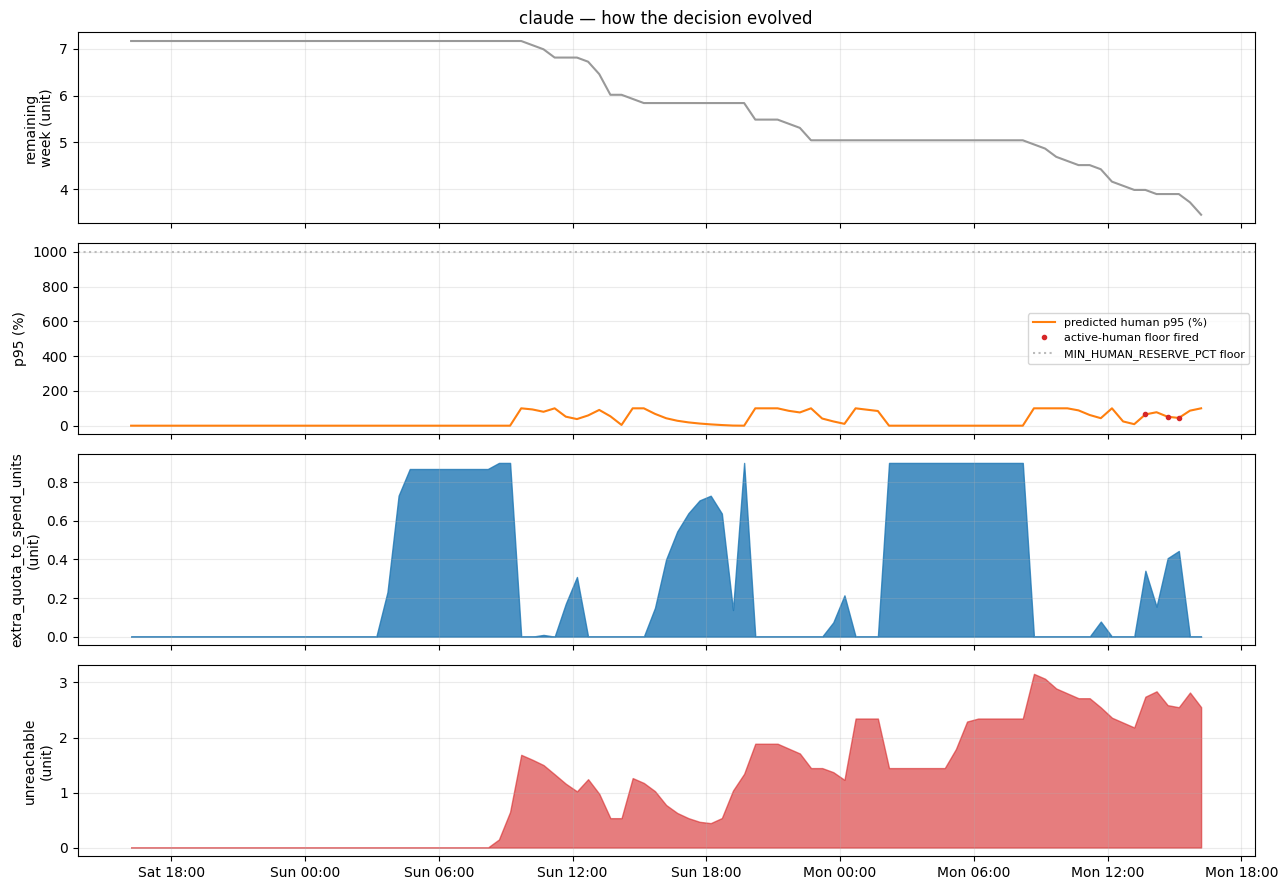

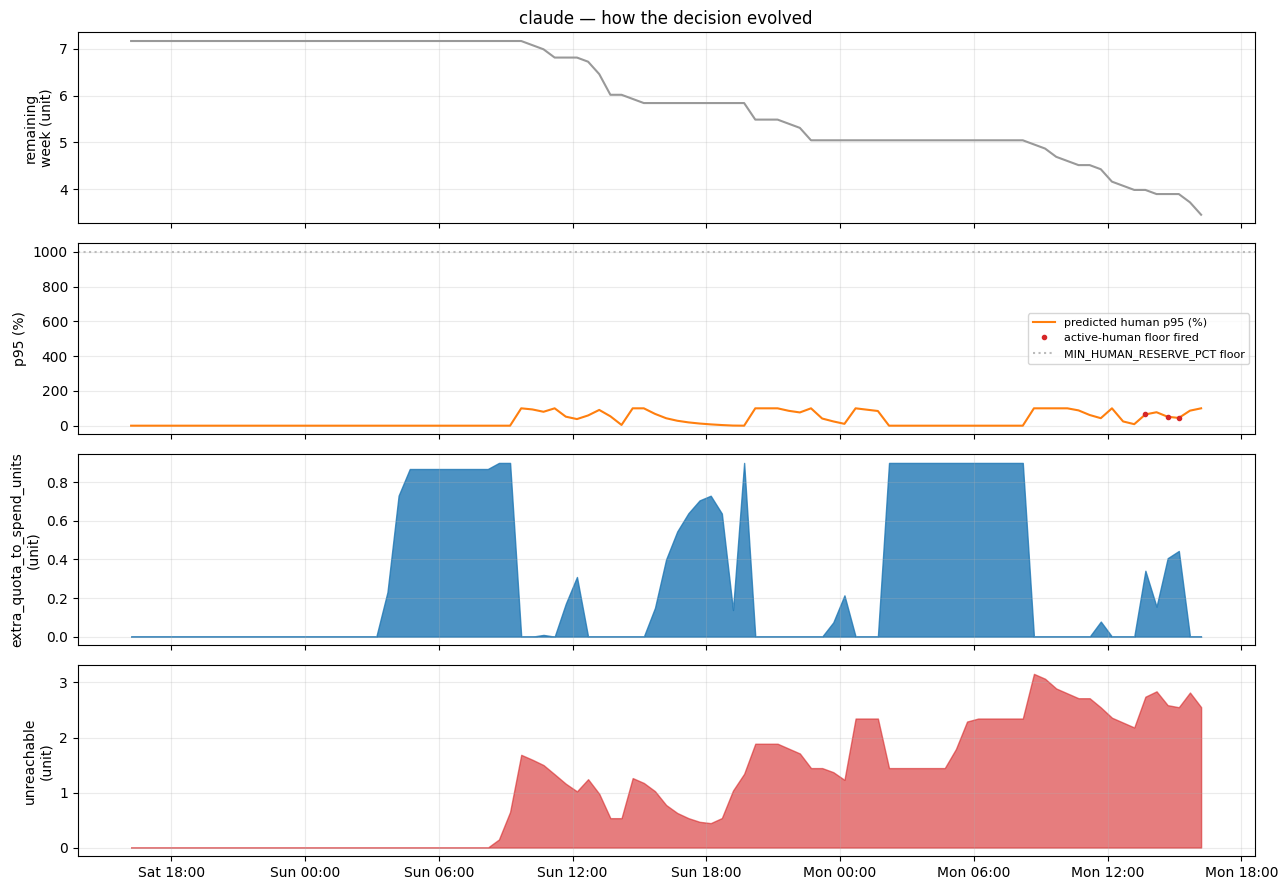

In [10]:
frame = sweep(hours=48, step_minutes=30)
plot_sweep(frame, AGENT)

In [11]:
# Where the decision changed, and why.
changes = frame[frame["agent"] == AGENT].copy()
changes = changes[changes["verdict"].ne(changes["verdict"].shift())]
changes[["when", "verdict", "extra_quota_to_spend_units", "already_lost_units",
            "predicted_p95_human_usage_pct", "based_on", "remaining_windows"]]

,when,verdict,extra_quota_to_spend_units,already_lost_units,predicted_p95_human_usage_pct,based_on,remaining_windows
0,2026-10-03 16:11:44+02:00,wait,0.0000,0.0000,0.0000,nothing,11
46,2026-10-04 03:41:44+02:00,spend_now,0.2307,0.0000,0.0000,nothing,9
70,2026-10-04 09:41:44+02:00,wait,0.0000,1.6852,100.0000,current_window,8
74,2026-10-04 10:41:44+02:00,spend_now,0.0089,1.4993,80.1142,current_window,8
76,2026-10-04 11:11:44+02:00,wait,0.0000,1.3312,100.0000,last_30_min,8
78,2026-10-04 11:41:44+02:00,spend_now,0.1708,1.1604,51.9243,current_window,8
82,2026-10-04 12:41:44+02:00,wait,0.0000,1.2427,58.9600,last_30_min,8
94,2026-10-04 15:41:44+02:00,spend_now,0.1490,1.0253,68.0971,current_window,7
112,2026-10-04 20:11:44+02:00,wait,0.0000,1.8870,100.0000,current_window,5
126,2026-10-04 23:41:44+02:00,spend_now,0.0741,1.3704,24.5858,current_window,5
